# $y=ax+b$ から始めるベイズ推論

このチュートリアルは、原稿「逆アプローチによるベイズ計測の応用と
スペクトル解析の高度化」の線形モデル（2.3節、4.2節）を、手元で再現するためのものです。
目標は次の3点です。

1. 最小二乗法の点推定と、ベイズ推定の分布推定を同じデータで比較する。
2. 交換モンテカルロ法（EMC）の温度列から
   $F(\sigma^2)=-\log p(\mathbf{y}\mid\sigma^2)$ を評価し、雑音分散を選ぶ。
3. $a,b$ の95%信用区間、相関、平均直線の不確かさ、観測値の事後予測帯を読む。

数式番号は原稿との対応を示すために記しますが、説明とコードはこのNotebook用に再構成しています。
`BAYES_XPS_FAST=1` を設定すると、動作確認用にburn-in、保存サンプル数、
チューニング試行を短縮します。最終的な図や数値を得るときは通常モードを使ってください。

In [1]:
from pathlib import Path
import csv
import json
import os
import subprocess
import sys
import warnings

import numpy as np


try:
    import google.colab  # type: ignore  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    colab_repo = Path("/content/bayesian-xps-spectral-analysis")
    if not colab_repo.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/motigome/bayesian-xps-spectral-analysis.git",
                str(colab_repo),
            ],
            check=True,
        )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", f"{colab_repo}[plot]"],
        check=True,
    )
    os.chdir(colab_repo / "tutorials" / "01_linear_model")
    print("Colab setup completed.")


def find_project_dir():
    """Notebook、percent script、リポジトリ直下のどこからでも同じ場所を使う。"""
    candidates = []
    if "__file__" in globals():
        candidates.append(Path(__file__).resolve().parent)
    cwd = Path.cwd().resolve()
    candidates.extend([cwd, cwd / "tutorials" / "01_linear_model"])
    for candidate in candidates:
        if (candidate / "config.json").exists() and (candidate / "src" / "target.hpp").exists():
            return candidate
    raise FileNotFoundError(
        "tutorials/01_linear_model が見つかりません。"
        "リポジトリ直下またはチュートリアルディレクトリから実行してください。"
    )


PROJECT_DIR = find_project_dir()
REPO_ROOT = PROJECT_DIR.parents[1]
DATA_DIR = PROJECT_DIR / "data"
RESULT_DIR = PROJECT_DIR / "result"
SRC_DIR = PROJECT_DIR / "src"
DATA_DIR.mkdir(exist_ok=True)
(RESULT_DIR / "figures").mkdir(parents=True, exist_ok=True)

# Matplotlibのキャッシュもチュートリアルディレクトリ内に限定する。
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_DIR / ".matplotlib"))

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 日本語フォントがある環境ではそれを使う。ない環境では図中を英語表記にし、
# 不要なmissing-glyph警告だけを抑える（Markdown本文の日本語には影響しない）。
font_candidates = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP"]
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
selected_font = next((name for name in font_candidates if name in installed_fonts), "DejaVu Sans")
mpl.rcParams["font.family"] = selected_font
mpl.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore", message=r"Glyph .* missing from font")
warnings.filterwarnings("ignore", message=r"FigureCanvasAgg is non-interactive.*")

FAST_MODE = os.environ.get("BAYES_XPS_FAST", "0") == "1"
print(f"project: {PROJECT_DIR.relative_to(REPO_ROOT)}")
print(f"mode: {'FAST (smoke test)' if FAST_MODE else 'FULL'}")
print(f"matplotlib font: {selected_font}")

# ローカルのbayes_emcパッケージをCLIから確実に読めるようにする。
cli_env = os.environ.copy()
cli_env["PYTHONPATH"] = str(REPO_ROOT) + os.pathsep + cli_env.get("PYTHONPATH", "")
cli_env["MPLCONFIGDIR"] = str(PROJECT_DIR / ".matplotlib")


def run_cli(*args):
    """失敗時にNotebookを止める、bayes-emc CLIの小さなラッパー。"""
    command = [sys.executable, "-m", "bayes_emc", *map(str, args)]
    print("$ python -m bayes_emc", " ".join(map(str, args)))
    completed = subprocess.run(
        command,
        cwd=PROJECT_DIR,
        env=cli_env,
        text=True,
        capture_output=True,
    )
    for output in (completed.stdout, completed.stderr):
        cleaned = output.replace(str(REPO_ROOT), "<repo>").strip()
        if cleaned:
            print(cleaned)
    completed.check_returncode()

project: tutorials/01_linear_model
mode: FULL
matplotlib font: Hiragino Sans


## 1. 人工データを作る（原稿4.2.1節、式(48)）

原稿と同じ条件を使います。

- $N=50$、$x_i\in[-1,1]$（等間隔）
- 真値 $a=0.8$、$b=0.1$
- $\epsilon_i\sim\mathcal{N}(0,\sigma^2)$、$\sigma^2=0.01$

乱数シードも固定するため、再実行しても同じ観測値が得られます。

In [2]:
DATA_SEED = 12345
N = 50
A_TRUE = 0.8
B_TRUE = 0.1
SIGMA2_TRUE = 0.01

rng = np.random.default_rng(DATA_SEED)
x = np.linspace(-1.0, 1.0, N)
epsilon = rng.normal(loc=0.0, scale=np.sqrt(SIGMA2_TRUE), size=N)
y_true = A_TRUE * x + B_TRUE
y = y_true + epsilon

data_path = DATA_DIR / "data.csv"
np.savetxt(
    data_path,
    np.column_stack([x, y]),
    delimiter=",",
    header="x,y",
    comments="",
    fmt="%.12g",
)
print(f"wrote: {data_path.relative_to(PROJECT_DIR)}")
print(f"N={N}, a_true={A_TRUE}, b_true={B_TRUE}, sigma2_true={SIGMA2_TRUE}")

wrote: data/data.csv
N=50, a_true=0.8, b_true=0.1, sigma2_true=0.01


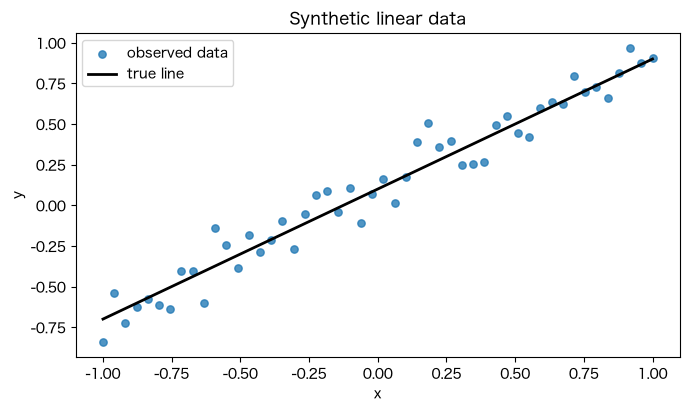

In [3]:
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.scatter(x, y, s=28, alpha=0.78, label="observed data")
ax.plot(x, y_true, color="black", linewidth=2.0, label="true line")
ax.set(xlabel="x", ylabel="y", title="Synthetic linear data")
ax.legend()
fig.tight_layout()
plt.show()

## 2. 確率モデルを読む（原稿2.3.1節、式(16)〜(21)）

観測モデルは

$$
y_i=ax_i+b+\epsilon_i,\qquad
\epsilon_i\sim\mathcal{N}(0,\sigma^2)
$$

です。$\boldsymbol{\theta}=(a,b)^\mathsf{T}$、設計行列の$i$行を
$(x_i,1)$ とすれば、$\mathbf{y}=X\boldsymbol{\theta}+\boldsymbol{\epsilon}$ と書けます。
独立なガウス雑音を仮定した尤度は

$$
p(\mathbf{y}\mid a,b,\sigma^2)
=(2\pi\sigma^2)^{-N/2}
\exp\!\left[-\frac{1}{2\sigma^2}
\sum_i\{y_i-(ax_i+b)\}^2\right]
$$

です。事前分布は原稿4.2.2節の条件に合わせて
$a,b\sim\mathrm{Uniform}(-1,1)$ とします。事後分布は

$$
p(a,b\mid\mathbf{y},\sigma^2)
\propto p(\mathbf{y}\mid a,b,\sigma^2)p(a,b)
$$

です。区間外の提案は事前確率0となるため棄却されます。

In [4]:
X = np.column_stack([x, np.ones_like(x)])
theta_true = np.array([A_TRUE, B_TRUE])
print("X shape:", X.shape)
print("theta_true:", theta_true)
print("first three mean values:", (X @ theta_true)[:3])

X shape: (50, 2)
theta_true: [0.8 0.1]
first three mean values: [-0.7        -0.66734694 -0.63469388]


## 3. 最小二乗法と比較する（原稿2.3.2節、式(22)〜(25)）

最小二乗法は残差二乗和を最小にする1点
$\hat{\boldsymbol{\theta}}=(X^\mathsf{T}X)^{-1}X^\mathsf{T}\mathbf{y}$
を返します。ここでは数値的に安定な `numpy.linalg.lstsq` を使います。
後で、同じデータから得たベイズ事後分布の幅と相関を比較します。

In [5]:
theta_lsq, *_ = np.linalg.lstsq(X, y, rcond=None)
a_lsq, b_lsq = theta_lsq
residual_lsq = y - X @ theta_lsq
sigma2_lsq_mle = np.mean(residual_lsq**2)

print(f"least-squares a = {a_lsq:.6f} (true {A_TRUE:.3f})")
print(f"least-squares b = {b_lsq:.6f} (true {B_TRUE:.3f})")
print(f"residual variance RSS/N = {sigma2_lsq_mle:.6f} (true {SIGMA2_TRUE:.3f})")

least-squares a = 0.812272 (true 0.800)
least-squares b = 0.106046 (true 0.100)
residual variance RSS/N = 0.010769 (true 0.010)


## 4. C++ `TargetFunction` を確認する

EMC本体は解析対象に依存しません。`src/target.hpp` に、現在の $a,b$ から
雑音を含まない平均 $ax+b$ を返す部分だけを書きます。
ガウス尤度、事前分布、EMC更新、自由エネルギー評価はCore側が担当します。

`params.Value(0, 0, 0)` と `params.Value(0, 0, 1)` は、次節のconfigに並べた
`a`, `b` にそれぞれ対応します。

In [6]:
print((SRC_DIR / "target.hpp").read_text(encoding="utf-8"))

#pragma once

#include "bayes_emc/bayes_emc.hpp"

#include <vector>

namespace bayes_emc_user {

// Parameter order follows config.json:
//   parameter 0: a (slope)
//   parameter 1: b (intercept)
// The Gaussian likelihood in the Core adds the observation-noise model, so
// this function returns only the conditional mean a * x + b.
inline void TargetFunction(
    const std::vector<double> & x,
    const bayes_emc::ParameterView & params,
    std::vector<double> & out
) {
    const double a = params.Value(0, 0, 0);
    const double b = params.Value(0, 0, 1);
    out[0] = a * x[0] + b;
}

} // namespace bayes_emc_user



## 5. configを読む

`config.json` の重要点は次のとおりです。

- `a`, `b` の事前分布はどちらも `Uniform(-1, 1)`。
- `estimate_sigma2=true` とし、温度列に対応する複数の $\sigma^2$ 候補を比較する。
- `sigma2_min=0.0025` は真値0.01より小さい探索下限。
- 逆温度 $\beta$ に対応する候補は $\sigma^2=\sigma^2_{\min}/\beta$。

このCoreでは $\sigma^2$ を連続変数として直接更新するのではなく、EMCの温度列に対応する
候補ごとの自由エネルギーを評価します。下のセルで、0.01付近の候補が
実際に温度列へ含まれることを先に確認します。

In [7]:
base_config_path = PROJECT_DIR / "config.json"
base_config = json.loads(base_config_path.read_text(encoding="utf-8"))

replica_num = int(base_config["emc"]["replica_num"])
gamma = float(base_config["emc"]["gamma"])
sigma2_min = float(base_config["model"]["noise"]["sigma2_min"])
inverse_temperatures = np.concatenate(
    ([0.0], gamma ** np.arange(2 - replica_num, 1, dtype=float))
)
sigma2_candidates = sigma2_min / inverse_temperatures[1:]
nearest_sigma2 = sigma2_candidates[np.argmin(np.abs(sigma2_candidates - SIGMA2_TRUE))]

assert base_config["model"]["noise"]["estimate_sigma2"] is True
assert sigma2_min < SIGMA2_TRUE
assert all(
    parameter["prior"] == {"type": "uniform", "lower": -1.0, "upper": 1.0}
    for parameter in base_config["model"]["models"][0]["parameters"]
)

print(f"replicas={replica_num}, gamma={gamma}, sigma2_min={sigma2_min}")
print(f"candidate nearest to true sigma2: {nearest_sigma2:.8f}")
print("nearby candidates:", np.sort(sigma2_candidates[np.abs(np.log(sigma2_candidates / SIGMA2_TRUE)) < 0.5]))

replicas=20, gamma=1.6, sigma2_min=0.0025
candidate nearest to true sigma2: 0.01024000
nearby candidates: [0.0064   0.01024  0.016384]


In [8]:
# 実行時間だけを切り替え、モデル・データ・事前分布・温度列は変えない。
run_sample_num = 400 if FAST_MODE else 5000
run_burnin_num = 500 if FAST_MODE else 5000
tune_sample_num = 50 if FAST_MODE else 250
tune_burnin_num = 80 if FAST_MODE else 300

runtime_config = json.loads(json.dumps(base_config))
runtime_config["emc"]["sample_num"] = run_sample_num
runtime_config["emc"]["burnin_num"] = run_burnin_num
runtime_config["emc"]["progress"] = False
runtime_config_path = PROJECT_DIR / "config.runtime.json"
runtime_config_path.write_text(
    json.dumps(runtime_config, indent=2, ensure_ascii=False) + "\n",
    encoding="utf-8",
)
print(f"runtime config: sample={run_sample_num}, burnin={run_burnin_num}")

runtime config: sample=5000, burnin=5000


## 6. `check` で入力を検証する

推論前に、JSON構造、CSV列、入出力次元、C++ソースの存在をCLIで確認します。
エラーがあればこのセルで停止するため、長い計算の後に設定ミスへ気づくのを防げます。

In [9]:
run_cli("check", runtime_config_path.name, "--sources")

$ python -m bayes_emc check config.runtime.json --sources
Config is valid.
data rows: 50
data path: <repo>/tutorials/01_linear_model/data/data.csv
data format: csv
data header: True
input columns: ['x']
output columns: ['y']
result dir: <repo>/tutorials/01_linear_model/result
parallel workers: 0 (0 means auto)
likelihood workers: 1 (0 means auto)
likelihood parallel min rows: 2048
progress: False
progress interval steps: 0 (0 means auto)
progress bar width: 32
noise model: gaussian
noise estimate sigma2: True
noise sigma2 min: 0.0025
noise finite ladder max sigma2: 11.805916207174125
noise sigma2 candidate count: 19
model layout:
  - linear: basis_count=1
    parameters: a, b
internal shape: model_type_num=1, base_nums=[1], hierarchy_nums=[1], parameter_nums=[[2]]


## 7. EMC設定を準備する

`config.tuned.json` がすでにあれば再利用します。なければ短いEMC試行で提案幅と
温度交換を確認し、同ファイルへ保存します。この線形問題では、0.01付近の雑音候補を
保つため温度列を `replica_num=20`, `gamma=1.6` に固定し、その列の中で提案幅の
スケールを調整します。

prior、モデル式、温度列を変更した後は、古い `config.tuned.json` を削除して
チューニングをやり直してください。

In [10]:
tuned_config_path = PROJECT_DIR / "config.tuned.json"
if tuned_config_path.exists():
    print(f"reuse tuned config: {tuned_config_path.relative_to(PROJECT_DIR)}")
else:
    run_cli(
        "tune",
        runtime_config_path.name,
        "--output-config", tuned_config_path.name,
        "--output-dir", "result/tuning",
        "--sample-num", str(tune_sample_num),
        "--burnin-num", str(tune_burnin_num),
        "--initial-replica-num", str(replica_num),
        "--max-replica-num", str(replica_num),
        "--gamma-min", str(gamma),
        "--gamma-max", str(gamma),
        "--gamma-candidates", "1",
        "--c-rounds", "1",
        "--d-rounds", "1" if FAST_MODE else "3",
        "--local-step-rounds", "0" if FAST_MODE else "1",
        "--keep-c",
        "--quiet",
    )

# チューニング結果から実行時間に関係する2項目だけを現在のモードに合わせる。
run_config = json.loads(tuned_config_path.read_text(encoding="utf-8"))
run_config["emc"]["sample_num"] = run_sample_num
run_config["emc"]["burnin_num"] = run_burnin_num
run_config["emc"]["progress"] = False
run_config_path = PROJECT_DIR / "config.run.json"
run_config_path.write_text(json.dumps(run_config, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
run_cli("check", run_config_path.name, "--sources")

reuse tuned config: config.tuned.json
$ python -m bayes_emc check config.run.json --sources


Config is valid.
data rows: 50
data path: <repo>/tutorials/01_linear_model/data/data.csv
data format: csv
data header: True
input columns: ['x']
output columns: ['y']
result dir: <repo>/tutorials/01_linear_model/result
parallel workers: 0 (0 means auto)
likelihood workers: 1 (0 means auto)
likelihood parallel min rows: 2048
progress: False
progress interval steps: 0 (0 means auto)
progress bar width: 32
noise model: gaussian
noise estimate sigma2: True
noise sigma2 min: 0.0025
noise finite ladder max sigma2: 11.805916207174125
noise sigma2 candidate count: 19
model layout:
  - linear: basis_count=1
    parameters: a, b
internal shape: model_type_num=1, base_nums=[1], hierarchy_nums=[1], parameter_nums=[[2]]


## 8. 交換モンテカルロ法を実行する

`run` はC++ CoreをビルドしてEMCを実行し、当該ディレクトリの `result/` に
サンプル、温度別診断、$F(\sigma^2)$、選択された事後分布を保存します。
Coreは隣接する2温度の正規化定数比を両方向の指数再重み付けで推定し、
それらを温度列に沿って累積して自由エネルギーを計算します。

In [11]:
run_cli("run", run_config_path.name)

$ python -m bayes_emc run config.run.json


samples: 5000
map_log_posterior: -27.6784
estimated_sigma2: 0.01024
noise_free_energy: -34.7256
diagnostic_warnings: 0
linear[0].default.a: 0.811967
linear[0].default.b: 0.10626
wrote <repo>/tutorials/01_linear_model/src/generated_v2_config.hpp
building: c++ main.cpp -o linear_model.out -I<repo>/tutorials/01_linear_model/src -I<repo>/cpp/include -std=c++20 -O2 -pthread
running: <repo>/tutorials/01_linear_model/src/linear_model.out
outputs:
  <repo>/tutorials/01_linear_model/result/sample.json
  <repo>/tutorials/01_linear_model/result/log.txt
  <repo>/tutorials/01_linear_model/result/noise_estimation.txt
  <repo>/tutorials/01_linear_model/result/diagnostics.tsv
  <repo>/tutorials/01_linear_model/result/diagnostics_warnings.tsv


## 9. EMC診断を確認する

`diagnostics.tsv` には各温度のMetropolis-Hastings採択率と隣接レプリカ交換率、
`diagnostics_warnings.tsv` には10%未満または99%超の簡易警告が入ります。
警告0は十分条件ではありませんが、温度空間を往復できているかを見る最初の確認になります。

In [12]:
sample = json.loads((RESULT_DIR / "sample.json").read_text(encoding="utf-8"))
posterior_replica_id = int(sample["posterior_replica_id"])

with (RESULT_DIR / "diagnostics.tsv").open(encoding="utf-8", newline="") as handle:
    diagnostic_rows = list(csv.DictReader(handle, delimiter="\t"))

warning_lines = (RESULT_DIR / "diagnostics_warnings.tsv").read_text(encoding="utf-8").splitlines()
print(f"posterior replica id: {posterior_replica_id}")
print("selected replica diagnostics:")
print(diagnostic_rows[posterior_replica_id])
if len(warning_lines) == 1:
    print("diagnostic warnings: none")
else:
    print("diagnostic warnings (first 10 rows):")
    print("\n".join(warning_lines[:11]))

posterior replica id: 16
selected replica diagnostics:
{'Inv Temp': '2.44e-01', 'linear[0].default.a': '34.22', 'linear[0].default.b': '31.64', 'Exchange %': '76.76', '<Energy>': '2.24e+00'}
diagnostic warnings: none


## 10. $F(\sigma^2)$ と推定雑音分散（原稿2.3.4節、4.2.2節）

`noise_estimation.txt` の各行は、1つの逆温度、対応する $\sigma^2$、
EMC温度列から得た自由エネルギーです。自由エネルギーが最小となる候補を
$\sigma^{2*}$ とします。有限データなので、$\sigma^{2*}$ は真値0.01と完全一致する
必要はなく、その近傍に選ばれるかを確認します。

true sigma2      = 0.01000000
estimated sigma2 = 0.01024000
selected replica = 16


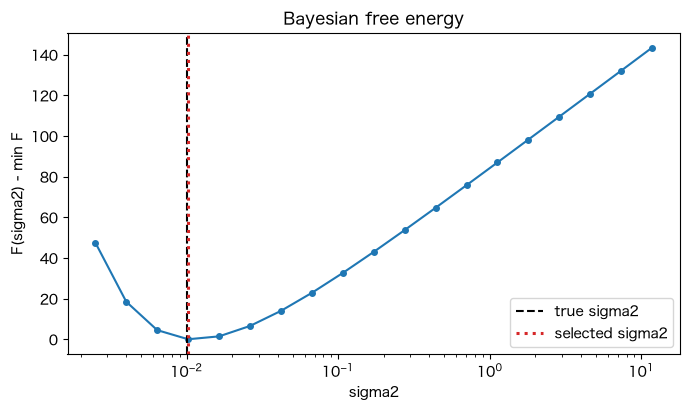

In [13]:
def read_noise_estimation(path):
    metadata = {}
    records = []
    for line in path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        if line.startswith("#"):
            key, value = line[1:].strip().split("\t", maxsplit=1)
            metadata[key] = value
            continue
        if line.startswith("sigma2"):
            continue
        sigma2_value, beta_value, free_energy_value = map(float, line.split())
        records.append((sigma2_value, beta_value, free_energy_value))
    return metadata, np.asarray(records, dtype=float)


noise_metadata, noise_records = read_noise_estimation(RESULT_DIR / "noise_estimation.txt")
order = np.argsort(noise_records[:, 0])
sigma2_values = noise_records[order, 0]
free_energies = noise_records[order, 2]
estimated_sigma2 = float(noise_metadata["estimated_sigma2"])

print(f"true sigma2      = {SIGMA2_TRUE:.8f}")
print(f"estimated sigma2 = {estimated_sigma2:.8f}")
print(f"selected replica = {noise_metadata['replica_id']}")

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(sigma2_values, free_energies - free_energies.min(), "o-", markersize=4)
ax.axvline(SIGMA2_TRUE, color="black", linestyle="--", label="true sigma2")
ax.axvline(estimated_sigma2, color="#d62728", linestyle=":", linewidth=2.2, label="selected sigma2")
ax.set_xscale("log")
ax.set(xlabel="sigma2", ylabel="F(sigma2) - min F", title="Bayesian free energy")
ax.legend()
fig.tight_layout()
plt.show()

## 11. $a,b$ の事後分布（原稿4.2.3節、式(50)）

`sample.json` には、$\sigma^{2*}$ に対応する温度層のサンプルが保存されています。
周辺事後分布の中央値と95%信用区間を計算し、同時分布から相関係数も求めます。
信用区間は「このモデル・事前分布・データのもとでパラメータが入る確率区間」であり、
頻度論的な信頼区間とは解釈が異なります。

In [14]:
labels = [parameter["label"] for parameter in sample["parameters"]]
posterior_values = np.asarray(sample["samples"]["values"], dtype=float)
a_index = labels.index("linear[0].default.a")
b_index = labels.index("linear[0].default.b")
a_samples = posterior_values[:, a_index]
b_samples = posterior_values[:, b_index]


def posterior_summary(values):
    lower, median, upper = np.quantile(values, [0.025, 0.5, 0.975])
    return {"mean": float(np.mean(values)), "median": float(median), "lower": float(lower), "upper": float(upper)}


a_summary = posterior_summary(a_samples)
b_summary = posterior_summary(b_samples)
ab_correlation = float(np.corrcoef(a_samples, b_samples)[0, 1])

print(
    f"a: mean={a_summary['mean']:.6f}, median={a_summary['median']:.6f}, "
    f"95% CI=[{a_summary['lower']:.6f}, {a_summary['upper']:.6f}], true={A_TRUE:.3f}"
)
print(
    f"b: mean={b_summary['mean']:.6f}, median={b_summary['median']:.6f}, "
    f"95% CI=[{b_summary['lower']:.6f}, {b_summary['upper']:.6f}], true={B_TRUE:.3f}"
)
print(f"corr(a, b)={ab_correlation:.4f}")

a: mean=0.812130, median=0.811996, 95% CI=[0.762128, 0.860281], true=0.800
b: mean=0.106201, median=0.106375, 95% CI=[0.078055, 0.133848], true=0.100
corr(a, b)=0.0130


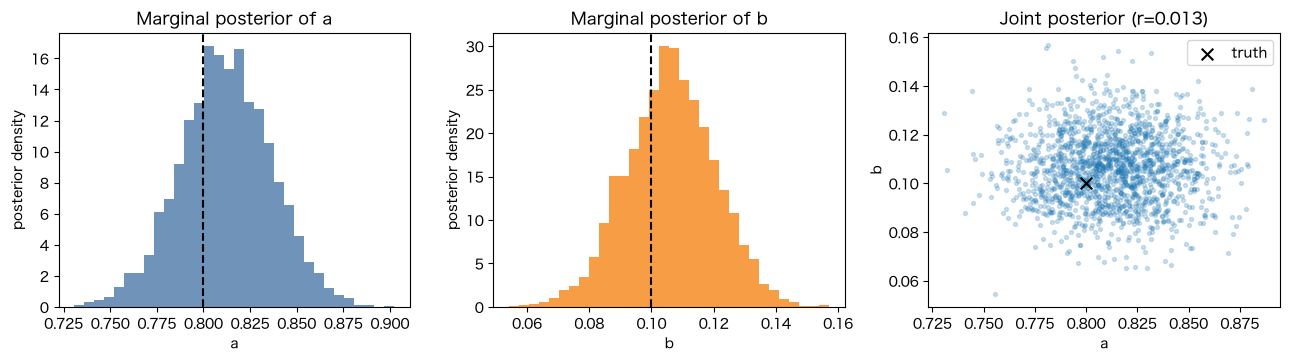

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.7))
axes[0].hist(a_samples, bins=32, density=True, color="#4c78a8", alpha=0.8)
axes[0].axvline(A_TRUE, color="black", linestyle="--")
axes[0].set(xlabel="a", ylabel="posterior density", title="Marginal posterior of a")

axes[1].hist(b_samples, bins=32, density=True, color="#f58518", alpha=0.8)
axes[1].axvline(B_TRUE, color="black", linestyle="--")
axes[1].set(xlabel="b", ylabel="posterior density", title="Marginal posterior of b")

plot_stride = max(1, len(a_samples) // 1500)
axes[2].scatter(a_samples[::plot_stride], b_samples[::plot_stride], s=8, alpha=0.22)
axes[2].scatter([A_TRUE], [B_TRUE], marker="x", s=70, color="black", label="truth")
axes[2].set(xlabel="a", ylabel="b", title=f"Joint posterior (r={ab_correlation:.3f})")
axes[2].legend()
fig.tight_layout()
plt.show()

## 12. 平均直線と観測値の事後予測帯

各事後サンプル $(a^{(s)},b^{(s)})$ から平均直線
$a^{(s)}x+b^{(s)}$ を描けば、回帰直線そのものの不確かさが得られます。
さらに $\mathcal{N}(0,\sigma^{2*})$ の新しい観測雑音を加えると、
未観測の $y$ に対する事後予測分布になります。後者の帯が広いのは、
パラメータ不確かさに加えて1回ごとの測定雑音も含むためです。

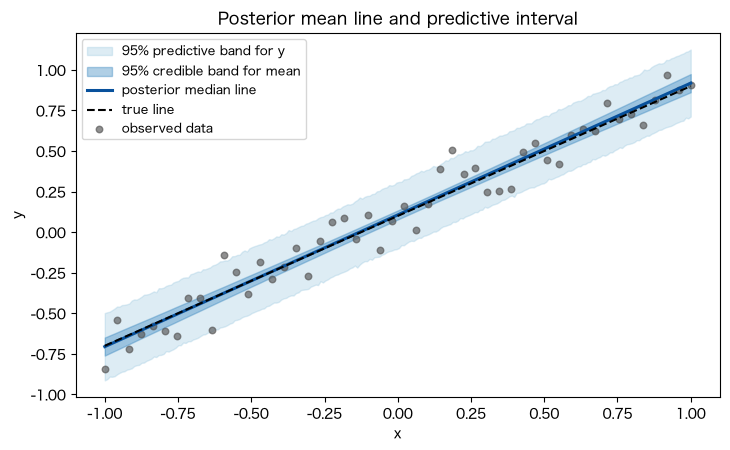

In [16]:
x_prediction = np.linspace(-1.0, 1.0, 240)
mean_draws = a_samples[:, None] * x_prediction[None, :] + b_samples[:, None]
mean_lower, mean_median, mean_upper = np.quantile(mean_draws, [0.025, 0.5, 0.975], axis=0)

predictive_rng = np.random.default_rng(54321)
observation_draws = mean_draws + predictive_rng.normal(
    loc=0.0,
    scale=np.sqrt(estimated_sigma2),
    size=mean_draws.shape,
)
obs_lower, _, obs_upper = np.quantile(observation_draws, [0.025, 0.5, 0.975], axis=0)

fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.fill_between(x_prediction, obs_lower, obs_upper, color="#9ecae1", alpha=0.35, label="95% predictive band for y")
ax.fill_between(x_prediction, mean_lower, mean_upper, color="#3182bd", alpha=0.38, label="95% credible band for mean")
ax.plot(x_prediction, mean_median, color="#08519c", linewidth=2.2, label="posterior median line")
ax.plot(x_prediction, A_TRUE * x_prediction + B_TRUE, color="black", linestyle="--", label="true line")
ax.scatter(x, y, s=22, color="#555555", alpha=0.65, label="observed data")
ax.set(xlabel="x", ylabel="y", title="Posterior mean line and predictive interval")
ax.legend(loc="best", fontsize=9)
fig.tight_layout()
plt.show()

## 13. まとめとXPSスペクトル分解への橋渡し

この例では、最小二乗法が返す1本の直線に加えて、ベイズ推定から次を得ました。

- EMC温度列による $F(\sigma^2)$ と $\sigma^{2*}$
- $a,b$ の95%信用区間と相関
- 平均直線の信用帯と、新しい観測値の事後予測帯

XPSスペクトル分解でも手順は同じです。直線 $ax+b$ をピークの和に置き換え、
$a,b$ の代わりにピーク位置 $\mu_k$、幅 $w_k$、強度 $A_k$ を推定します。
線形例で雑音分散ごとの $F(\sigma^2)$ を比較した位置には、候補ピーク数ごとの
$F(K)$ の比較が入り、最小値を与える $K^*$ を選びます。次のスペクトル分解
チュートリアルでは、この「モデルを選んでから、そのモデル内の不確かさを読む」流れを扱います。

### 演習

1. `DATA_SEED` を変え、有限データでは $\sigma^{2*}$ がどの程度動くか確かめる。
2. $N$ を増減し、$a,b$ の信用区間と平均直線の帯がどう変わるか比較する。
3. `config.json` の一様事前分布を狭めた後、`config.tuned.json` を削除して再実行し、
   事前分布が事後分布と自由エネルギーへ与える影響を調べる。